## Function 7: Overlay & Visualize 🗺️

In this notebook, you'll learn how to build the `overlay_and_visualize()` function step by step. This is where you combine spatial layers using overlay operations and create visual outputs to communicate your results clearly.

### 🎯 What This Function Does
- Perform intersection, union, and difference overlays
- Create matplotlib visualizations
- Calculate overlay statistics
- Save maps to files

### 🔧 Function Signature
```python
def overlay_and_visualize(gdf1, gdf2=None, overlay_how='intersection', save_path=None):
    """
    Args:
        gdf1 (geopandas.GeoDataFrame): First spatial dataset
        gdf2 (geopandas.GeoDataFrame, optional): Second spatial dataset
        overlay_how (str): Overlay operation to perform
        save_path (str or Path, optional): File path for saving the figure
    
    Returns:
        dict: Overlay result, figure, and statistics
    """
```

### 📍 Where This Function Goes:
**Target File**: `src/geopandas_basics.py`  
**Function Name**: `overlay_and_visualize()`  
**Replace**: The placeholder function with your working code

---

### ⚙️ Step 0: Select the Correct Python Kernel

Before running any cells, make sure the notebook is using the correct Python environment.

**Check the kernel in the top-right corner of the notebook.**

The correct Python environment is **python-gis-development (.venv)**  
It may appear with a Python version, for example:  
**python-gis-development (3.11.15) (Python 3.11.15) .venv/bin/python**



If the kernel is **python-gis-development (.venv)**, you can start running cells below.

Steps to select the correct kernel:
1. Click on the kernel (top right corner of the notebook) if it is not **python-gis-development (.venv)** or if it says "Select Kernel"
2. Select **python-gis-development (.venv)**
3. If you do not see the kernel in the list, click on "Select Another Kernel..."  
    a. Click on Python Environments...   
    b. Select **python-gis-development (.venv)**

Once the correct kernel is selected, you can start running cells below.

### 📚 Step 1: Load Data for Overlay Operations

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Load datasets
ecoregions = gpd.read_file('../../data/ecoregions/epa_level3_western_us.geojson')
parks = gpd.read_file('../../data/protected_areas/national_parks_major.geojson')

# Get a subset for clearer visualization
parks_subset = parks.iloc[:5]  # First 5 parks
eco_subset = ecoregions.iloc[:3]  # First 3 ecoregions

print("✅ Loaded:")
print(f"   Ecoregions: {len(ecoregions)} total ({len(eco_subset)} for examples)")
print(f"   Parks: {len(parks)} total ({len(parks_subset)} for examples)")

✅ Loaded:
   Ecoregions: 188 total (3 for examples)
   Parks: 37 total (5 for examples)


### 🗺️ Step 2: Visualization 1 - Overlay Operations Grid

Master ALL overlay types - see how each creates different results


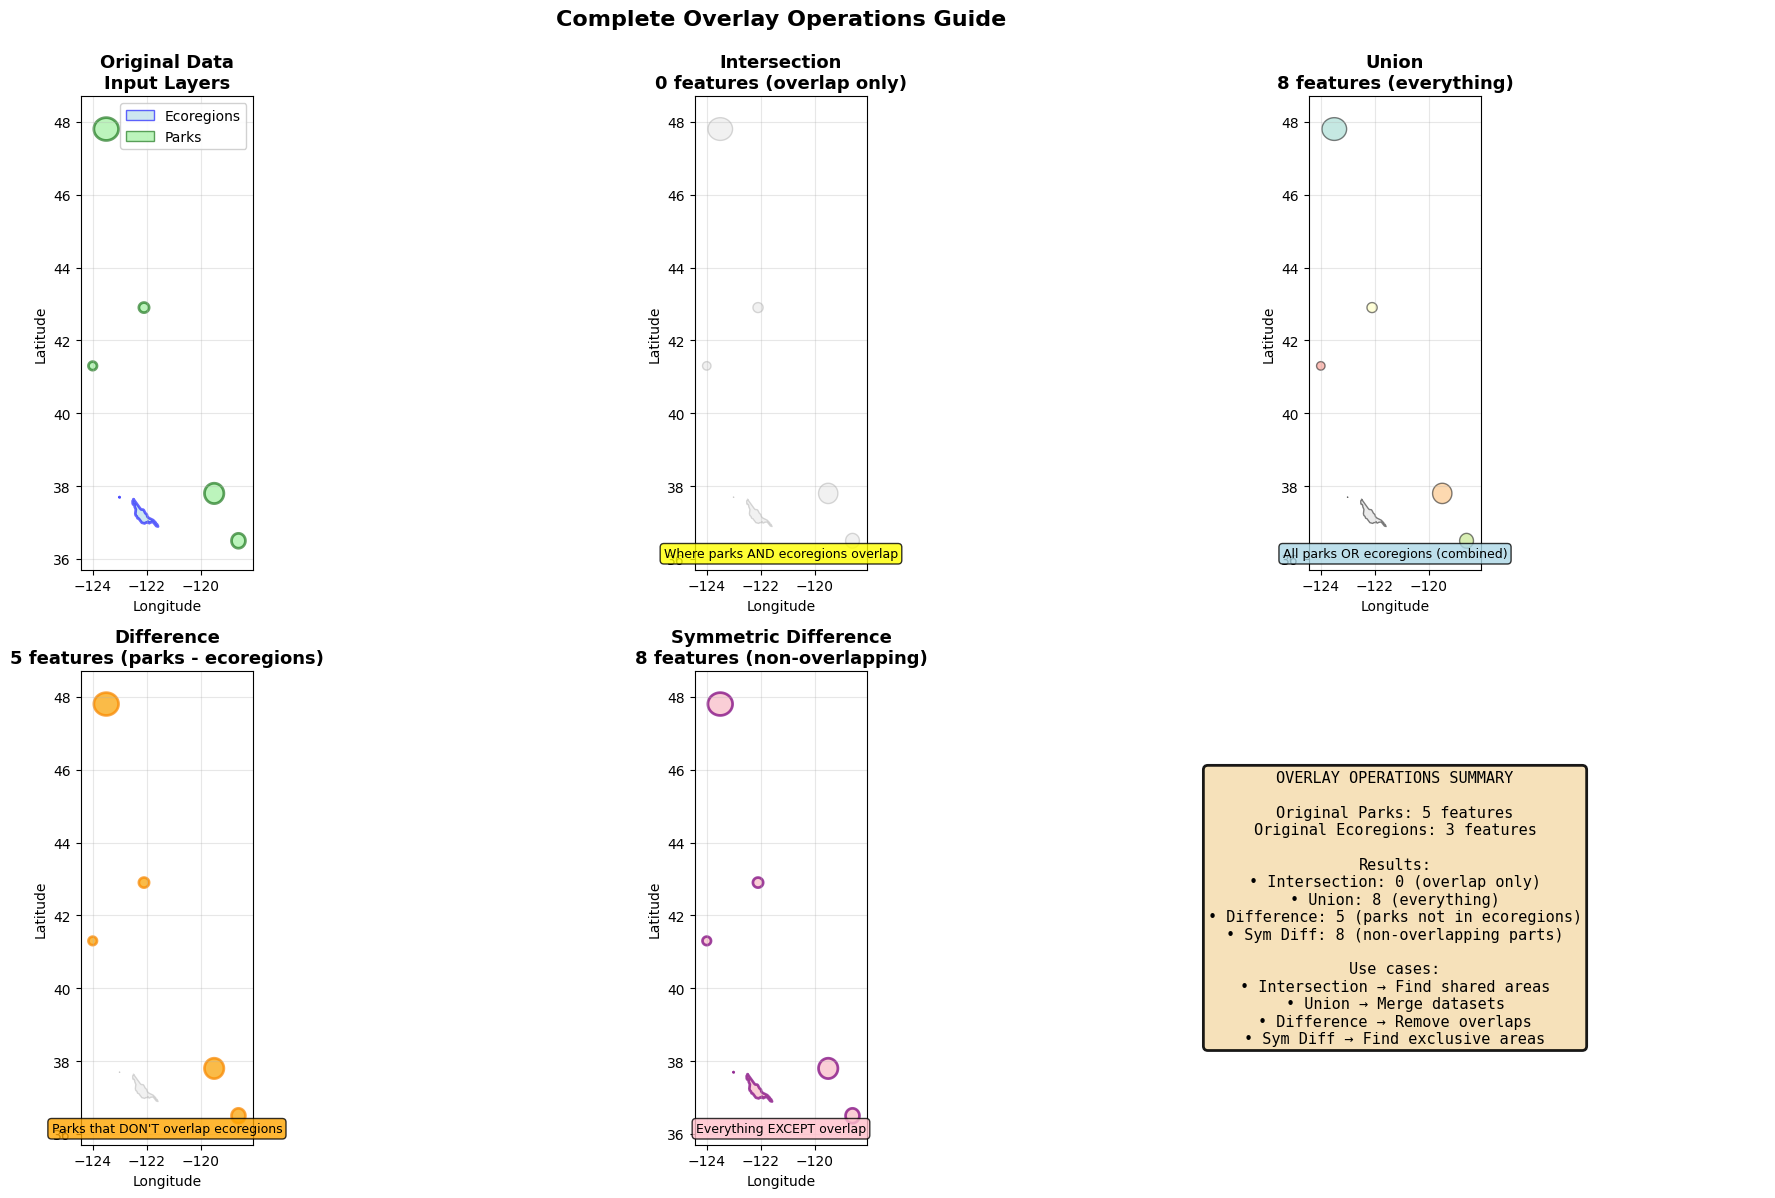

🎯 Overlay operations completed:
   Intersection: 0 features
   Union: 8 features
   Difference: 5 features
   Symmetric Difference: 8 features


In [2]:
# Perform all 4 overlay operations
try:
    intersection = gpd.overlay(parks_subset, eco_subset, how='intersection')
    union = gpd.overlay(parks_subset, eco_subset, how='union')
    difference = gpd.overlay(parks_subset, eco_subset, how='difference')
    symmetric_difference = gpd.overlay(parks_subset, eco_subset, how='symmetric_difference')
    
    # Create 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()
    
    # 1. ORIGINAL DATA
    # This code snippet fixes a UserWarning for creation of legends.
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightblue', edgecolor='blue', label='Ecoregions', alpha=0.6),
        Patch(facecolor='lightgreen', edgecolor='darkgreen', label='Parks', alpha=0.6)
    ]
    axes[0].legend(handles=legend_elements, fontsize=10, framealpha=0.9)
    
    eco_subset.plot(ax=axes[0], color='lightblue', edgecolor='blue', linewidth=2, alpha=0.6, label='Ecoregions')
    parks_subset.plot(ax=axes[0], color='lightgreen', edgecolor='darkgreen', linewidth=2, alpha=0.6, label='Parks')
    axes[0].set_title("Original Data\nInput Layers", fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].grid(True, alpha=0.3)
    
    # 2. INTERSECTION (overlap only)
    eco_subset.plot(ax=axes[1], color='lightgray', edgecolor='gray', linewidth=1, alpha=0.3)
    parks_subset.plot(ax=axes[1], color='lightgray', edgecolor='gray', linewidth=1, alpha=0.3)
    if len(intersection) > 0:
        intersection.plot(ax=axes[1], color='yellow', edgecolor='red', linewidth=2, alpha=0.8)
    axes[1].set_title(f"Intersection\n{len(intersection)} features (overlap only)", fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].grid(True, alpha=0.3)
    axes[1].text(0.5, 0.02, "Where parks AND ecoregions overlap",
                transform=axes[1].transAxes, ha='center', va='bottom',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8), fontsize=9)
    
    # 3. UNION (everything)
    if len(union) > 0:
        union.plot(ax=axes[2], color='purple', edgecolor='black', linewidth=1, alpha=0.5, cmap='Set3')
    axes[2].set_title(f"Union\n{len(union)} features (everything)", fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.5, 0.02, "All parks OR ecoregions (combined)",
                transform=axes[2].transAxes, ha='center', va='bottom',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), fontsize=9)
    
    # 4. DIFFERENCE (A minus B)
    eco_subset.plot(ax=axes[3], color='lightgray', edgecolor='gray', linewidth=1, alpha=0.3)
    parks_subset.plot(ax=axes[3], color='lightgray', edgecolor='gray', linewidth=1, alpha=0.3)
    if len(difference) > 0:
        difference.plot(ax=axes[3], color='orange', edgecolor='darkorange', linewidth=2, alpha=0.7)
    axes[3].set_title(f"Difference\n{len(difference)} features (parks - ecoregions)", fontsize=13, fontweight='bold')
    axes[3].set_xlabel('Longitude')
    axes[3].set_ylabel('Latitude')
    axes[3].grid(True, alpha=0.3)
    axes[3].text(0.5, 0.02, "Parks that DON'T overlap ecoregions",
                transform=axes[3].transAxes, ha='center', va='bottom',
                bbox=dict(boxstyle='round', facecolor='orange', alpha=0.8), fontsize=9)
    
    # 5. SYMMETRIC DIFFERENCE (A xor B)
    eco_subset.plot(ax=axes[4], color='lightgray', edgecolor='gray', linewidth=1, alpha=0.3)
    parks_subset.plot(ax=axes[4], color='lightgray', edgecolor='gray', linewidth=1, alpha=0.3)
    if len(symmetric_difference) > 0:
        symmetric_difference.plot(ax=axes[4], color='pink', edgecolor='purple', linewidth=2, alpha=0.7)
    axes[4].set_title(f"Symmetric Difference\n{len(symmetric_difference)} features (non-overlapping)", fontsize=13, fontweight='bold')
    axes[4].set_xlabel('Longitude')
    axes[4].set_ylabel('Latitude')
    axes[4].grid(True, alpha=0.3)
    axes[4].text(0.5, 0.02, "Everything EXCEPT overlap",
                transform=axes[4].transAxes, ha='center', va='bottom',
                bbox=dict(boxstyle='round', facecolor='pink', alpha=0.8), fontsize=9)
    
    # 6. SUMMARY TABLE
    axes[5].axis('off')
    summary_text = "OVERLAY OPERATIONS SUMMARY\n\n"
    summary_text += f"Original Parks: {len(parks_subset)} features\n"
    summary_text += f"Original Ecoregions: {len(eco_subset)} features\n\n"
    summary_text += "Results:\n"
    summary_text += f"• Intersection: {len(intersection)} (overlap only)\n"
    summary_text += f"• Union: {len(union)} (everything)\n"
    summary_text += f"• Difference: {len(difference)} (parks not in ecoregions)\n"
    summary_text += f"• Sym Diff: {len(symmetric_difference)} (non-overlapping parts)\n\n"
    summary_text += "Use cases:\n"
    summary_text += "• Intersection → Find shared areas\n"
    summary_text += "• Union → Merge datasets\n"
    summary_text += "• Difference → Remove overlaps\n"
    summary_text += "• Sym Diff → Find exclusive areas"
    
    axes[5].text(0.5, 0.5, summary_text,
                transform=axes[5].transAxes,
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=2),
                fontsize=11, family='monospace')
    
    plt.suptitle("Complete Overlay Operations Guide", fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print("🎯 Overlay operations completed:")
    print(f"   Intersection: {len(intersection)} features")
    print(f"   Union: {len(union)} features")
    print(f"   Difference: {len(difference)} features")
    print(f"   Symmetric Difference: {len(symmetric_difference)} features")
    
except Exception as e:
    print(f"⚠️  Overlay demonstration skipped: {str(e)}")
    print("   (This can happen if geometries don't overlap enough)")


---

### 🗺️ Step 3: Visualization 2 - Professional Styled Map

Create publication-quality cartography with legends, titles, and annotations

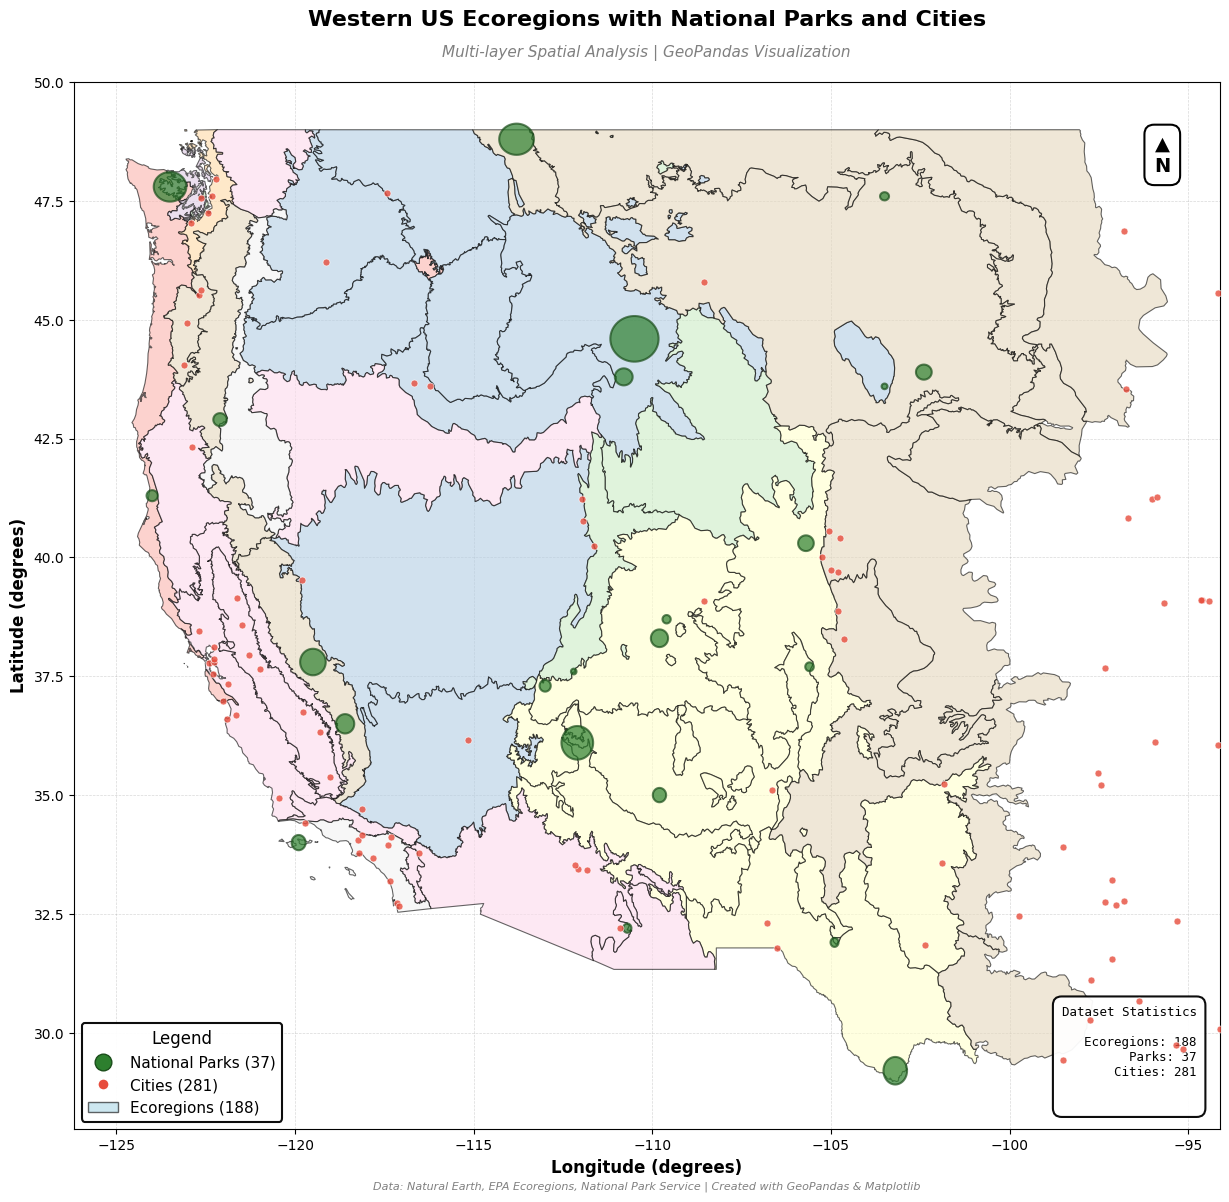

✅ Professional map created!
   Quality: Publication-ready
   Features: Styled layers, legend, north arrow, citation, statistics
   This demonstrates professional cartographic standards


In [3]:
# Load full datasets for professional map
cities = gpd.read_file('../../data/cities/ne_cities_us.geojson')

# Create professional-quality figure
fig, ax = plt.subplots(figsize=(16, 12))

# Base layer - ecoregions with subtle colors
ecoregions.plot(ax=ax, 
               column='US_L3CODE' if 'US_L3CODE' in ecoregions.columns else None,
               cmap='Pastel1',
               edgecolor='black',
               linewidth=0.8,
               alpha=0.6,
               legend=False)

# Parks layer - prominent green
parks.plot(ax=ax,
          color='#2d7f2e',  # Forest green
          edgecolor='#1a4d1a',
          linewidth=1.5,
          alpha=0.7,
          label='National Parks')

# Cities layer - prominent red
cities.plot(ax=ax,
           color='#e74c3c',  # Professional red
           markersize=25,
           alpha=0.8,
           edgecolor='white',
           linewidth=0.5,
           label='Cities',
           zorder=5)

# Professional title with subtitle
title = "Western US Ecoregions with National Parks and Cities"
subtitle = "Multi-layer Spatial Analysis | GeoPandas Visualization"
ax.text(0.5, 1.05, title,
       transform=ax.transAxes,
       ha='center', va='bottom',
       fontsize=16, fontweight='bold')
ax.text(0.5, 1.02, subtitle,
       transform=ax.transAxes,
       ha='center', va='bottom',
       fontsize=11, style='italic', color='gray')

# Axis labels
ax.set_xlabel('Longitude (degrees)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude (degrees)', fontsize=12, fontweight='bold')

# Zoom to ecoregions extent (Western US focus)
minx, miny, maxx, maxy = ecoregions.total_bounds
# Add small buffer for aesthetics (5% padding)
x_buffer = (maxx - minx) * 0.05
y_buffer = (maxy - miny) * 0.05
ax.set_xlim(minx - x_buffer, maxx + x_buffer)
ax.set_ylim(miny - y_buffer, maxy + y_buffer)

# Professional gridlines
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
ax.set_axisbelow(True)  # Grid behind data

# Custom legend with counts
legend_elements = [
    Line2D([0], [0], marker='o', color='w', 
          markerfacecolor='#2d7f2e', markersize=12, 
          label=f'National Parks ({len(parks)})', linewidth=2, markeredgecolor='#1a4d1a'),
    Line2D([0], [0], marker='o', color='w', 
          markerfacecolor='#e74c3c', markersize=8, 
          label=f'Cities ({len(cities)})', markeredgecolor='white'),
    Rectangle((0, 0), 1, 1, facecolor='lightblue', edgecolor='black', alpha=0.6,
             label=f'Ecoregions ({len(ecoregions)})')
]
legend = ax.legend(handles=legend_elements,
                  loc='lower left',
                  fontsize=11,
                  framealpha=0.95,
                  edgecolor='black',
                  title='Legend',
                  title_fontsize=12)
legend.get_frame().set_linewidth(1.5)

# Add north arrow (simple text-based)
ax.text(0.95, 0.95, '▲\nN',
       transform=ax.transAxes,
       ha='center', va='top',
       fontsize=14, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=1.5))

# Add data source citation
citation = "Data: Natural Earth, EPA Ecoregions, National Park Service | Created with GeoPandas & Matplotlib"
ax.text(0.5, -0.05, citation,
       transform=ax.transAxes,
       ha='center', va='top',
       fontsize=8, style='italic', color='gray')

# Add statistics box
stats_text = "Dataset Statistics\n\n"
stats_text += f"Ecoregions: {len(ecoregions)}\n"
stats_text += f"Parks: {len(parks)}\n"
stats_text += f"Cities: {len(cities)}\n\n"

ax.text(0.98, 0.02, stats_text,
       transform=ax.transAxes,
       ha='right', va='bottom',
       bbox=dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.95, edgecolor='black', linewidth=1.5),
       fontsize=9, family='monospace')

plt.tight_layout()
plt.show()

print("✅ Professional map created!")
print("   Quality: Publication-ready")
print("   Features: Styled layers, legend, north arrow, citation, statistics")
print("   This demonstrates professional cartographic standards")


---

### 🏗️ Step 5: Building the Complete Function

Now let's put everything together into a reusable function. This is what you will implement in `src/geopandas_basics.py`.

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Dict, Any, Optional, Union
from pathlib import Path

def overlay_and_visualize(
    gdf1: gpd.GeoDataFrame,
    gdf2: Optional[gpd.GeoDataFrame] = None,
    overlay_how: str = 'intersection',
    save_path: Optional[Union[str, Path]] = None
) -> Dict[str, Any]:
    """
    Perform overlay operations and create visualizations.
    
    Combines two spatial datasets using geometric overlay operations
    and generates both static and interactive visualizations.
    
    Overlay operations:
    - 'intersection': Areas where both datasets overlap
    - 'union': Combined areas from both datasets
    - 'difference': Areas in gdf1 not in gdf2
    - 'symmetric_difference': Areas in either but not both
    
    Args:
        gdf1: First GeoDataFrame
        gdf2: Second GeoDataFrame (optional for visualization only)
        overlay_how: Type of overlay operation
        save_path: Optional path to save the visualization
        
    Returns:
        Dictionary containing:
        - 'overlay_result': GeoDataFrame with overlay results (if gdf2 provided)
        - 'figure': Matplotlib figure object
        - 'statistics': Dictionary of geometry counts and areas
        
    Raises:
        ValueError: If inputs are invalid or overlay operation fails
        
    Example:
        >>> # Find intersection of two polygon layers
        >>> result = overlay_and_visualize(parks, flood_zones, 'intersection')
        >>> overlay_gdf = result['overlay_result']
        >>> print(f"Intersection area: {overlay_gdf.geometry.area.sum()}")
        
        >>> # Just visualize a single layer
        >>> result = overlay_and_visualize(cities, save_path='cities_map.png')
        >>> plt.show()
    """   
    result = {}
    
    # If gdf2 is provided, perform overlay operation
    if gdf2 is not None:
        # Validate inputs
        if not isinstance(gdf1, gpd.GeoDataFrame) or not isinstance(gdf2, gpd.GeoDataFrame):
            raise ValueError("Both inputs must be GeoDataFrames")
        
        # Check CRS compatibility
        if gdf1.crs != gdf2.crs:
            raise ValueError(
                f"CRS mismatch: gdf1 has {gdf1.crs}, gdf2 has {gdf2.crs}. "
                "Transform to same CRS before overlay."
            )
        
        # Validate overlay operation
        valid_operations = ['intersection', 'union', 'difference', 'symmetric_difference']
        if overlay_how not in valid_operations:
            raise ValueError(
                f"Invalid overlay operation '{overlay_how}'. "
                f"Must be one of: {', '.join(valid_operations)}"
            )
        
        # Perform overlay
        overlay_result = gpd.overlay(gdf1, gdf2, how=overlay_how)
        result['overlay_result'] = overlay_result
        
        # Calculate statistics
        stats = {
            'operation': overlay_how,
            'input1_count': len(gdf1),
            'input2_count': len(gdf2),
            'output_count': len(overlay_result),
        }
        
        # Calculate areas if geometry is polygons and result is not empty
        if len(overlay_result) > 0:
            geom_type = overlay_result.geometry.geom_type.iloc[0]
            if geom_type in ['Polygon', 'MultiPolygon']:
                # Use projected CRS for area calculation if in geographic CRS
                if overlay_result.crs and overlay_result.crs.is_geographic:
                    overlay_proj = overlay_result.to_crs('EPSG:6933')  # Equal Area
                    total_area_km2 = overlay_proj.geometry.area.sum() / 1e6
                else:
                    total_area_km2 = overlay_result.geometry.area.sum() / 1e6
                stats['total_area_km2'] = float(total_area_km2)
        
        result['statistics'] = stats
        
        # Create visualization
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        if len(overlay_result) > 0:
            overlay_result.plot(ax=ax, alpha=0.7, edgecolor='black', cmap='viridis')
        else:
            # Plot original datasets if overlay is empty
            gdf1.plot(ax=ax, alpha=0.5, edgecolor='red')
            gdf2.plot(ax=ax, alpha=0.5, edgecolor='blue')

            legend_elements = [
                Patch(facecolor='none', edgecolor='red', label='GDF1'),
                Patch(facecolor='none', edgecolor='blue', label='GDF2')
            ]
            ax.legend(handles=legend_elements)
        ax.set_title(f"Overlay Result: {overlay_how.title()}", fontsize=14)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        plt.tight_layout()
        
    else:
        # Visualization only (no overlay)
        result['statistics'] = {
            'feature_count': len(gdf1),
            'geometry_types': gdf1.geometry.geom_type.unique().tolist()
        }
        
        # Create visualization
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        gdf1.plot(ax=ax, alpha=0.7, edgecolor='black', cmap='viridis')
        ax.set_title("Spatial Data Visualization", fontsize=14)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        plt.tight_layout()
    
    result['figure'] = fig
    
    # Save figure if path provided
    if save_path:
        save_path = Path(save_path)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        result['saved_path'] = str(save_path)
    
    return result

### ✨ Step 6: Test Your Function

Let's test our complete function with different scenarios:

Test 1: Overlay with two GeoDataFrames
✅ Returned keys: ['overlay_result', 'statistics', 'figure']
✅ Overlay result features: 0

Test 2: Different overlay operations
✅ Intersection features: 0
✅ Union features: 8
✅ Difference features: 5

Test 3: Returned dictionary structure
✅ Has 'overlay_result': True
✅ Has 'figure': True
✅ Has 'statistics': True

Test 4: Visualization only
✅ Returned keys: ['statistics', 'figure']
✅ Feature count: 3
✅ Geometry types: ['Polygon']

Test 5: Error handling - CRS mismatch
✅ Correctly raised ValueError: CRS mismatch: gdf1 has EPSG:5070, gdf2 has EPSG:4326. Transform to same CRS before overlay.

Test 6: Error handling - invalid overlay type
✅ Correctly raised ValueError: Invalid overlay operation 'invalid_overlay'. Must be one of: intersection, union, difference, symmetric_difference

Test 7: Save figure to disk
✅ Figure saved to: overlay_test.png

🎉 All tests completed!


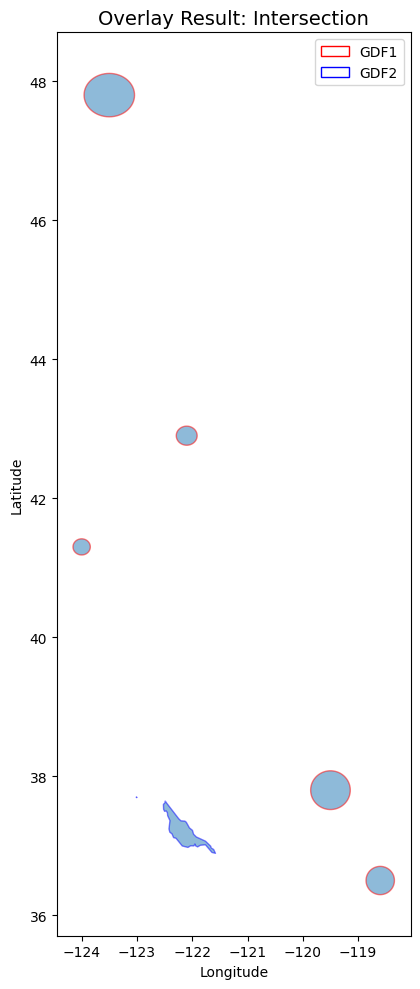

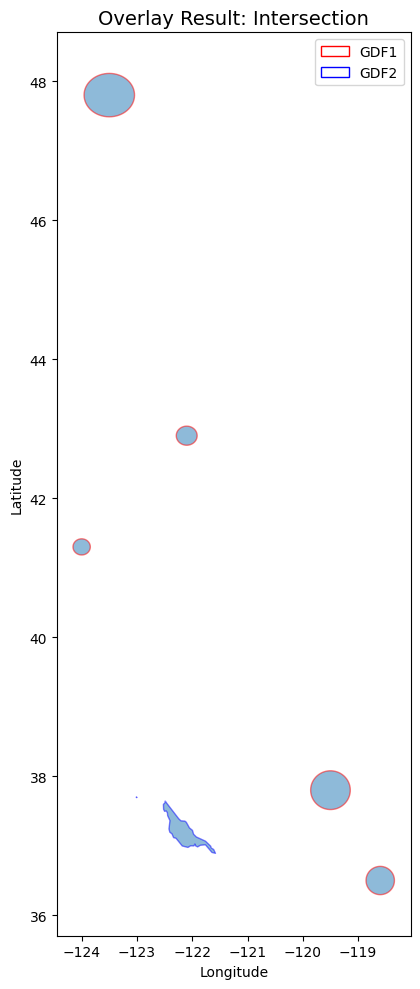

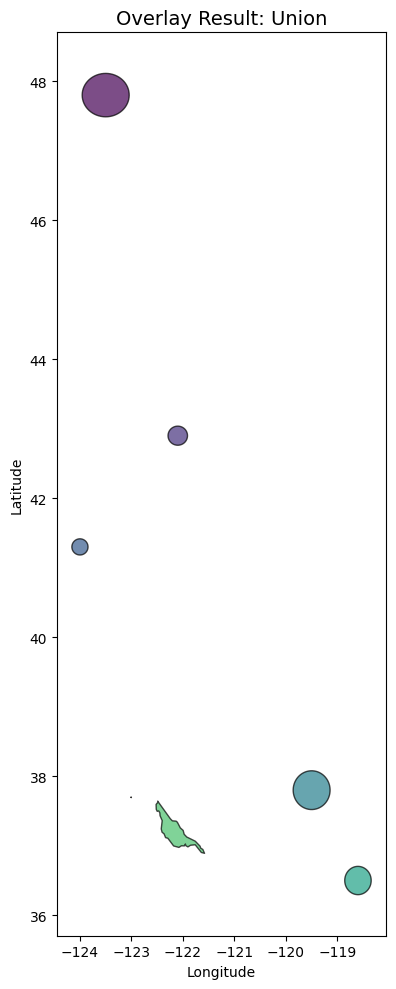

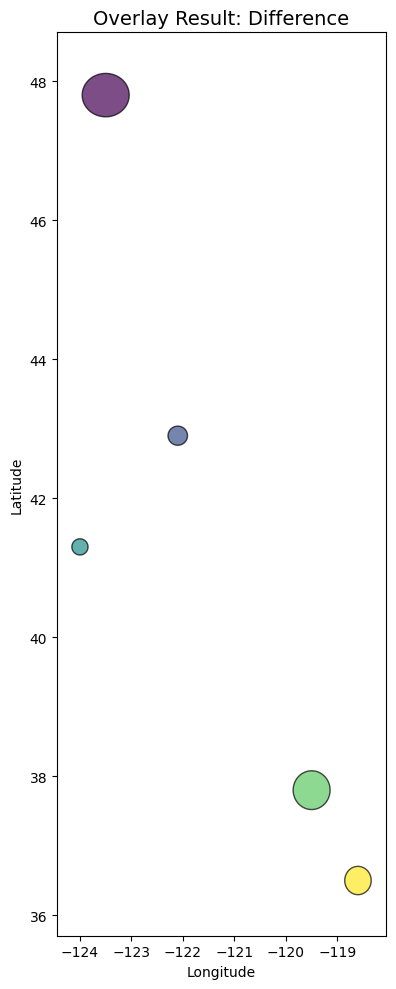

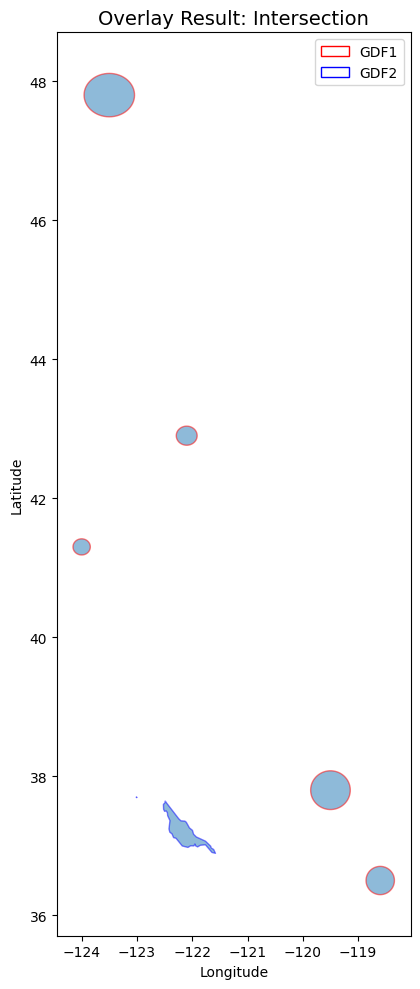

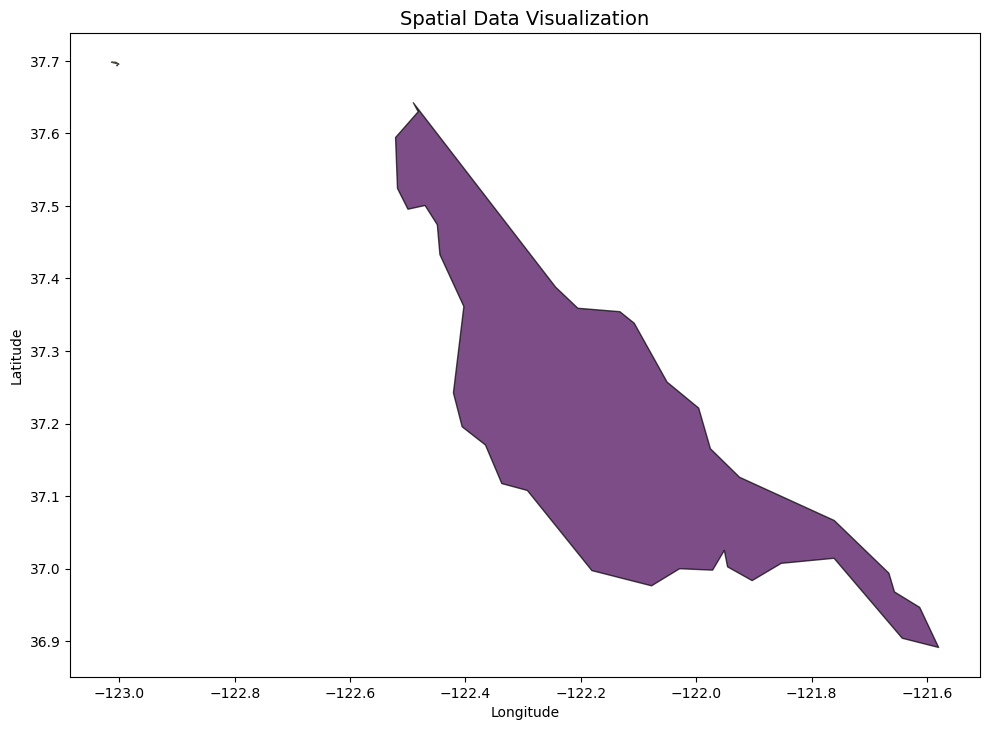

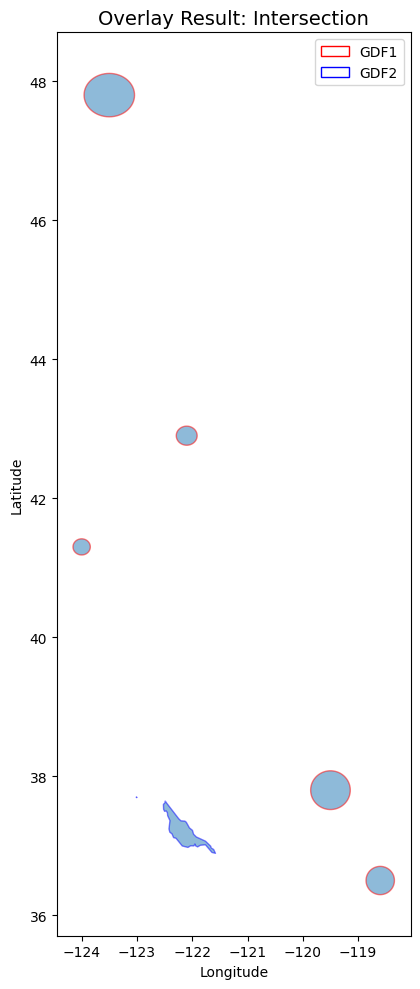

In [5]:
# Test 1: Overlay with two GeoDataFrames
print("Test 1: Overlay with two GeoDataFrames")
result = overlay_and_visualize(parks_subset, eco_subset, overlay_how='intersection')
print(f"✅ Returned keys: {list(result.keys())}")
print(f"✅ Overlay result features: {len(result['overlay_result'])}")
print()

# Test 2: Different overlay operations
print("Test 2: Different overlay operations")

result_intersection = overlay_and_visualize(parks_subset, eco_subset, overlay_how='intersection')
print(f"✅ Intersection features: {len(result_intersection['overlay_result'])}")

result_union = overlay_and_visualize(parks_subset, eco_subset, overlay_how='union')
print(f"✅ Union features: {len(result_union['overlay_result'])}")

result_difference = overlay_and_visualize(parks_subset, eco_subset, overlay_how='difference')
print(f"✅ Difference features: {len(result_difference['overlay_result'])}")
print()

# Test 3: Check returned dictionary structure
print("Test 3: Returned dictionary structure")
result = overlay_and_visualize(parks_subset, eco_subset, overlay_how='intersection')
print(f"✅ Has 'overlay_result': {'overlay_result' in result}")
print(f"✅ Has 'figure': {'figure' in result}")
print(f"✅ Has 'statistics': {'statistics' in result}")
print()

# Test 4: Visualization with one GeoDataFrame only
print("Test 4: Visualization only")
result = overlay_and_visualize(eco_subset)
print(f"✅ Returned keys: {list(result.keys())}")
print(f"✅ Feature count: {result['statistics']['feature_count']}")
print(f"✅ Geometry types: {result['statistics']['geometry_types']}")
print()

# Test 5: Error handling - CRS mismatch
print("Test 5: Error handling - CRS mismatch")
try:
    parks_proj = parks_subset.to_crs("EPSG:5070")
    overlay_and_visualize(parks_proj, eco_subset, overlay_how='intersection')
except ValueError as e:
    print(f"✅ Correctly raised ValueError: {e}")
print()

# Test 6: Error handling - invalid overlay type
print("Test 6: Error handling - invalid overlay type")
try:
    overlay_and_visualize(parks_subset, eco_subset, overlay_how='invalid_overlay')
except ValueError as e:
    print(f"✅ Correctly raised ValueError: {e}")
print()

# Test 7: Save figure to disk
print("Test 7: Save figure to disk")
result = overlay_and_visualize(parks_subset, eco_subset, overlay_how='intersection', save_path='overlay_test.png')
print(f"✅ Figure saved to: {result['saved_path']}")
print()

print("🎉 All tests completed!")

### 🧪 Step 7: Verify with Pytest

After implementing in `src/geopandas_basics.py`:

```bash
uv run pytest tests/test_geopandas_basics.py::TestOverlayAndVisualize -v
```

**⚠️ IMPORTANT: Make sure this passes before you move on!**

---

### 🔑 Key Learning Points

- **`gpd.overlay()`** performs boolean overlay operations between spatial layers
- **`intersection`** keeps only overlapping areas
- **`union`** combines all areas from both datasets
- **`difference`** keeps areas in one dataset that do not overlap the other
- **`symmetric_difference`** keeps non-overlapping parts from both datasets
- Overlay results can be summarized with counts and area statistics
- Good visualization helps communicate spatial analysis clearly and professionally